In [3]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [4]:
df2 = pd.read_csv('C:\\Users\\minvy\\Desktop\lavai\\aisdk-2025-05-16.csv')

<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\minvy\AppData\Local\Temp\ipykernel_18736\2690548241.py:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  df2 = pd.read_csv('C:\\Users\\minvy\\Desktop\lavai\\aisdk-2025-05-16.csv')


In [ ]:
df2.shape

(24256059, 26)

In [5]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 24256059 entries, 0 to 24256058
Data columns (total 26 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   # Timestamp                     str    
 1   Type of mobile                  str    
 2   MMSI                            int64  
 3   Latitude                        float64
 4   Longitude                       float64
 5   Navigational status             str    
 6   ROT                             float64
 7   SOG                             float64
 8   COG                             float64
 9   Heading                         float64
 10  IMO                             str    
 11  Callsign                        str    
 12  Name                            str    
 13  Ship type                       str    
 14  Cargo type                      str    
 15  Width                           float64
 16  Length                          float64
 17  Type of position fixing device  str 

In [7]:
# randam missing values
df2.isnull().sum()

# Timestamp                              0
Type of mobile                           0
MMSI                                     0
Latitude                                 0
Longitude                                0
Navigational status                      0
ROT                                7467767
SOG                                1732541
COG                                3356872
Heading                            5204692
IMO                                      0
Callsign                                 0
Name                               1874916
Ship type                                0
Cargo type                        19768599
Width                              2372482
Length                             2365780
Type of position fixing device           0
Draught                            6554042
Destination                           5287
ETA                                8850111
Data source type                         0
A                                  2421792
B          

In [8]:
df2.isnull().sum()/df2.shape[0]*100

# Timestamp                        0.000000
Type of mobile                     0.000000
MMSI                               0.000000
Latitude                           0.000000
Longitude                          0.000000
Navigational status                0.000000
ROT                               30.787223
SOG                                7.142714
COG                               13.839313
Heading                           21.457286
IMO                                0.000000
Callsign                           0.000000
Name                               7.729681
Ship type                          0.000000
Cargo type                        81.499633
Width                              9.780987
Length                             9.753357
Type of position fixing device     0.000000
Draught                           27.020226
Destination                        0.021797
ETA                               36.486187
Data source type                   0.000000
A                               

Kadangi Cargo Type stulpelis turi daugiau nei 50% praleistų reikšmių (81,4%), šį stulpelį mes panaikinsime.

In [ ]:
df2.drop(labels='Cargo type', axis=1)

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,16/05/2025 00:00:00,Class A,219023834,54.858782,10.842985,Under way using engine,NaN,13.9,181.0,178.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
5,16/05/2025 00:00:00,Class A,257182000,57.468657,11.482785,Under way using engine,0.0,21.5,342.9,342.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
8,16/05/2025 00:00:00,Base Station,2190064,56.716548,11.519055,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24256054,16/05/2025 23:59:58,Class A,257016650,57.118833,8.591713,Under way using engine,0.0,0.0,129.1,240.0,...,20.0,GPS,5.3,FISHING,NaN,AIS,12.0,8.0,5.0,4.0
24256055,16/05/2025 23:59:58,Class A,311000330,54.501822,14.098455,Under way using engine,0.0,11.2,353.0,351.0,...,168.0,GPS,5.9,SCIE->YSTAD->SCIE,17/05/2025 04:40:00,AIS,18.0,150.0,10.0,18.0
24256056,16/05/2025 23:59:58,Class A,219017843,57.713902,10.591423,Engaged in fishing,0.0,0.0,197.0,131.0,...,70.0,GPS,7.5,800 CLEAR BEHIND,10/01/2026 23:00:00,AIS,50.0,20.0,7.0,7.0
24256057,16/05/2025 23:59:58,Class A,255915983,56.373183,11.471025,Under way using engine,0.2,8.0,210.9,214.0,...,144.0,GPS,6.5,DKKAL,17/05/2025 06:00:00,AIS,115.0,29.0,16.0,7.0


In [13]:
# randam duplicate
key = ["MMSI", "# Timestamp"]
df2.duplicated(subset=key).sum()

np.int64(58671)

In [ ]:
before = len(df2)
df2 = df2.drop_duplicates(subset=key, keep="first").copy()
after = len(df2)
print("Pašalinta dublikatų:", before - after)
print("Liko eilučių:", after)

Pašalinta dublikatų: 58671
Liko eilučių: 11722431


In [16]:
# randam garbage values
for i in df2.select_dtypes(include=['object']).columns:
    print(df2[i].value_counts())
    print('*'*30)


C:\Users\minvy\AppData\Local\Temp\ipykernel_18736\2746771931.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df2.select_dtypes(include=['object']).columns:


# Timestamp
16/05/2025 22:27:21    543
16/05/2025 22:32:19    479
16/05/2025 22:32:18    463
16/05/2025 22:27:23    367
16/05/2025 22:27:22    326
                      ... 
16/05/2025 16:45:36      7
16/05/2025 16:45:12      6
16/05/2025 16:45:31      6
16/05/2025 16:45:22      5
16/05/2025 09:13:28      1
Name: count, Length: 86386, dtype: int64
******************************
Type of mobile
Class A                          10151753
Class B                           1112791
Base Station                       375580
AtoN                                81130
SAR Airborne                         1156
Search and Rescue Transponder          17
Emergency PIRB                          2
Man Overboard Device                    2
Name: count, dtype: int64
******************************
Navigational status
Under way using engine                                   6844057
Unknown value                                            2164119
Engaged in fishing                                       1530

In [18]:
name_counts = df2.groupby("MMSI")["Name"].nunique(dropna=True).sort_values(ascending=False)
name_counts.head(20)

MMSI
219030078    14
219004125     9
97000091      5
97000093      5
941004217     3
992351374     2
218795000     2
219019804     2
941004246     2
941004242     2
211158380     2
992351373     2
2320905       2
2320907       2
352005617     2
244830378     2
992651006     1
992651007     1
992651010     1
992651011     1
Name: Name, dtype: int64

In [19]:
mmsi_multi = name_counts[name_counts > 1]
mmsi_multi.shape, mmsi_multi.head(20)

((16,),
 MMSI
 219030078    14
 219004125     9
 97000091      5
 97000093      5
 941004217     3
 992351374     2
 218795000     2
 219019804     2
 941004246     2
 941004242     2
 211158380     2
 992351373     2
 2320905       2
 2320907       2
 352005617     2
 244830378     2
 Name: Name, dtype: int64)

In [20]:
name_map = (
    df2.dropna(subset=["Name"])
       .groupby("MMSI")["Name"]
       .agg(lambda s: s.value_counts().index[0])  # moda (dažniausia reikšmė)
)
missing_before = df2["Name"].isna().sum()
df2["Name_filled"] = df2["Name"].fillna(df2["MMSI"].map(name_map))
missing_after = df2["Name_filled"].isna().sum()
missing_before, missing_after

(np.int64(611935), np.int64(471558))

Filtruojam duomenis: pirma, kur COG ir HDG tarp 0 ir 360

In [15]:
# paliekam tik tuos įrašus, kur COG ir Heading tarp 0 ir 360
mask = df2['COG'].between(0, 360, inclusive='both') & df2['Heading'].between(0, 360, inclusive='both')
df2 = df2[mask].copy()
df2.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,16/05/2025 00:00:00,Class A,219023834,54.858782,10.842985,Under way using engine,NaN,13.9,181.0,178.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [14]:
df2.columns

Index(['# Timestamp', 'Type of mobile', 'MMSI', 'Latitude', 'Longitude',
       'Navigational status', 'ROT', 'SOG', 'COG', 'Heading', 'IMO',
       'Callsign', 'Name', 'Ship type', 'Cargo type', 'Width', 'Length',
       'Type of position fixing device', 'Draught', 'Destination', 'ETA',
       'Data source type', 'A', 'B', 'C', 'D'],
      dtype='str')

c:\Users\minvy\AppData\Local\Programs\Python\Python314\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\minvy\AppData\Local\Programs\Python\Python314\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\minvy\AppData\Local\Programs\Python\Python314\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


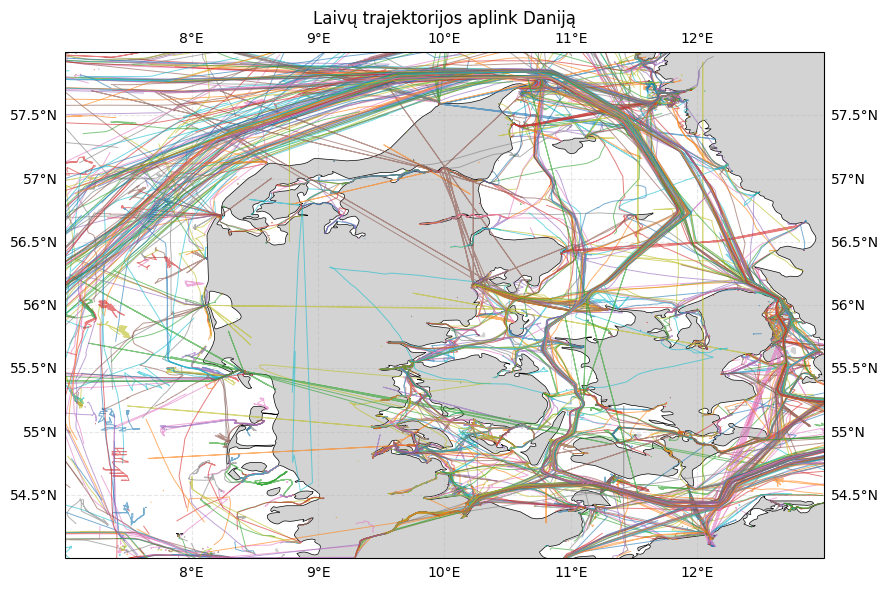

In [12]:
lat_min, lat_max = 54.0, 58.0
lon_min, lon_max = 7.0, 13.0

mask = (
    (df2["Latitude"]  >= lat_min) &
    (df2["Latitude"]  <= lat_max) &
    (df2["Longitude"] >= lon_min) &
    (df2["Longitude"] <= lon_max)
)

df_dk = df2[mask].copy()
f_dk = df_dk.sort_values("# Timestamp")

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)

# Fokusas į Danijos bbox
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Foninis žemėlapis
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# Kiekvienam laivui – atskira linija
for mmsi, g in df_dk.groupby("MMSI"):
    ax.plot(
        g["Longitude"].values,
        g["Latitude"].values,
        linewidth=0.7,
        alpha=0.6,
        transform=proj,
    )

ax.set_title("Laivų trajektorijos aplink Daniją")
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Trajektorijų segmentų skaičius: 4998


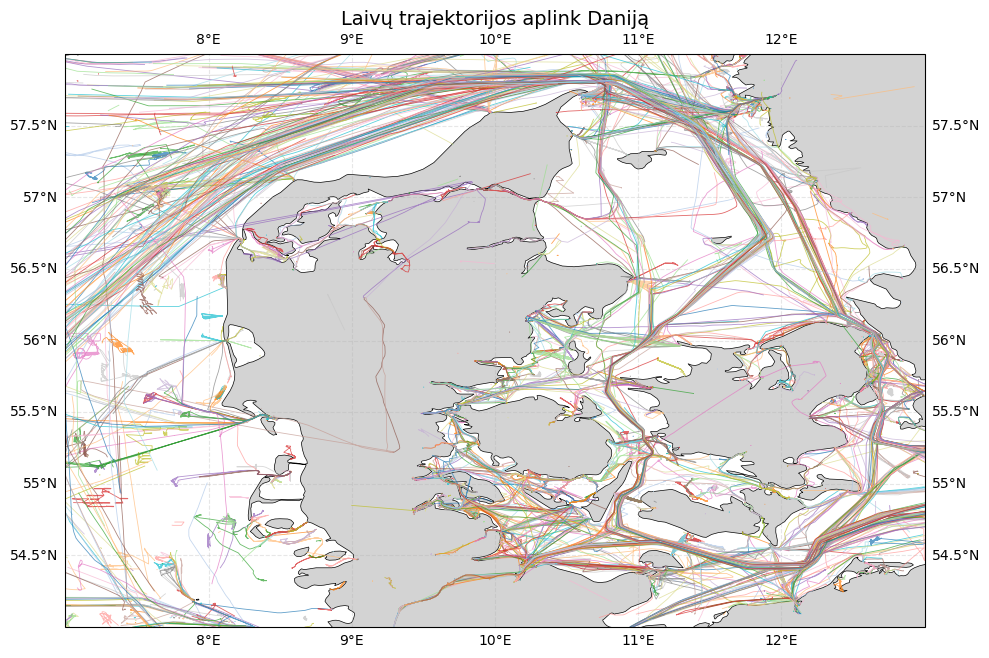

In [38]:
df2["# Timestamp"] = pd.to_datetime(df2["# Timestamp"])

# === 2. Filtras aplink Daniją (bbox – pasireguliuok ribas jei reikia) ===

lat_min, lat_max = 54.0, 58.0
lon_min, lon_max = 7.0, 13.0

mask = (
    (df2["Latitude"]  >= lat_min) &
    (df2["Latitude"]  <= lat_max) &
    (df2["Longitude"] >= lon_min) &
    (df2["Longitude"] <= lon_max)
)

df_dk = df2[mask].copy()
df_dk = df_dk.dropna(subset=["Latitude", "Longitude", "MMSI"])

# === 3. Išskaidom trajektorijas pagal MMSI ir atstumo šuolius ===

tracks = []
max_jump_km = 30.0   # virš šito atstumo – laikom nenatūraliu šuoliu

for mmsi, g in df_dk.groupby("MMSI"):
    g = g.sort_values("# Timestamp")

    if len(g) < 2:
        continue

    lat = np.deg2rad(g["Latitude"].values)
    lon = np.deg2rad(g["Longitude"].values)

    dlat = np.diff(lat)
    dlon = np.diff(lon)

    a = np.sin(dlat/2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    dist_km = 6371 * c  # Žemės spindulys km

    # indeksai, kur šuolis per didelis
    break_idx = np.where(dist_km > max_jump_km)[0] + 1

    # padalinam trajektoriją į dalis
    splits = np.split(g, break_idx)

    for s in splits:
        if len(s) >= 2:
            tracks.append(s)

print(f"Trajektorijų segmentų skaičius: {len(tracks)}")

# === 4. Piešiam ant geografinio žemėlapio ===

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)

# Fokusas į Danijos bbox
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Foninis žemėlapis
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# Spalvų ciklas skirtingoms trajektorijoms
from itertools import cycle
colors = cycle(plt.cm.tab20(np.linspace(0, 1, 20)))

for g in tracks:
    color = next(colors)
    ax.plot(
        g["Longitude"].values,
        g["Latitude"].values,
        linewidth=0.6,
        alpha=0.7,
        color=color,
        transform=proj,
    )

ax.set_title("Laivų trajektorijos aplink Daniją", fontsize=14)
plt.tight_layout()
plt.savefig("laivai_danija_tracks_clean.png", dpi=300)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/nump

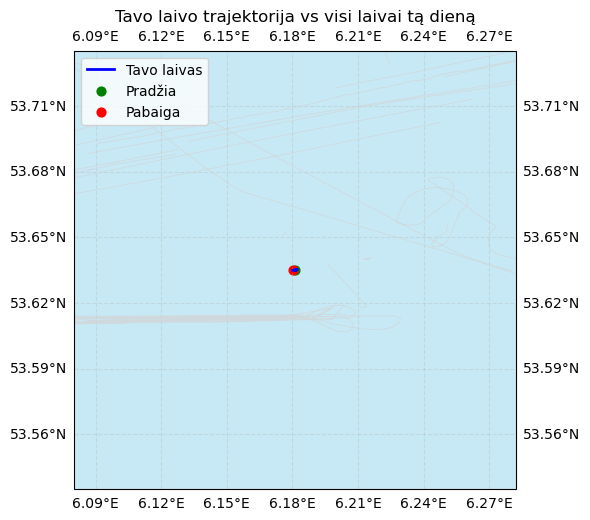

In [42]:
df2["# Timestamp"] = pd.to_datetime(df2["# Timestamp"], dayfirst=True)

# --- parametriai, KURIUOS PASIREGULIUOSI ---
target_mmsi = 311014800              # tavo „įdomus“ laivas
target_day = "2025-05-17"            # kuria diena lygini (yyyy-mm-dd)

# kvadratas – paimkim iš to laivo taškų (plius mažas bufferis),
# kad grafikas būtų kaip tavo paveikslėlyje
day_mask = df2["# Timestamp"].dt.date == pd.to_datetime(target_day).date()
df_day = df2[day_mask].copy()

target = df_day[df_day["MMSI"] == target_mmsi].sort_values("# Timestamp")
lat_min = target["Latitude"].min() - 0.1
lat_max = target["Latitude"].max() + 0.1
lon_min = target["Longitude"].min() - 0.1
lon_max = target["Longitude"].max() + 0.1

# ta pati diena, bet tik taškai kvadrate
box_mask = (
    (df_day["Latitude"]  >= lat_min) &
    (df_day["Latitude"]  <= lat_max) &
    (df_day["Longitude"] >= lon_min) &
    (df_day["Longitude"] <= lon_max)
)
df_box = df_day[box_mask].copy()

# --- funkcija – nedaryti šuolių per sausumą (jei nori – gali praleist) ---
# def split_by_jump(g, max_jump_km=5.0):
#     g = g.sort_values("# Timestamp")
#     if len(g) < 2:
#         return []

#     lat = np.deg2rad(g["Latitude"].values)
#     lon = np.deg2rad(g["Longitude"].values)
#     dlat = np.diff(lat)
#     dlon = np.diff(lon)
#     a = np.sin(dlat/2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2)**2
#     c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
#     dist_km = 6371 * c

#     break_idx = np.where(dist_km > max_jump_km)[0] + 1
#     return [s for s in np.split(g, break_idx) if len(s) >= 2]

# --- piešimas ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# fonas
ax.add_feature(cfeature.OCEAN, facecolor="#c7e9f5")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# 1) Visų tos dienos laivų trajektorijos (pilkai)
for mmsi, g in df_box.groupby("MMSI"):
    if mmsi == target_mmsi:
        continue
    for seg in split_by_jump(g, max_jump_km=5):
        ax.plot(
            seg["Longitude"].values,
            seg["Latitude"].values,
            color="lightgray",
            linewidth=0.6,
            alpha=0.7,
            transform=proj,
        )

# 2) Tavo laivo trajektorija tame pačiame kvadrate (ryškiai mėlyna)
target_box = df_box[df_box["MMSI"] == target_mmsi]
for seg in split_by_jump(target_box, max_jump_km=5):
    ax.plot(
        seg["Longitude"].values,
        seg["Latitude"].values,
        color="blue",
        linewidth=2,
        transform=proj,
        label="Tavo laivas",
    )

# pradžia/pabaiga to laivo
if not target_box.empty:
    tb = target_box.sort_values("# Timestamp")
    ax.scatter(tb["Longitude"].iloc[0], tb["Latitude"].iloc[0],
               color="green", s=40, transform=proj, label="Pradžia")
    ax.scatter(tb["Longitude"].iloc[-1], tb["Latitude"].iloc[-1],
               color="red", s=40, transform=proj, label="Pabaiga")

ax.set_title("Tavo laivo trajektorija vs visi laivai tą dieną")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("dienos_palyginimas.png", dpi=300)
plt.show()

In [43]:
print(df_day.head())

  # Timestamp Type of mobile       MMSI   Latitude  Longitude  \
0  2025-05-17        Class A  250370000  54.868457   7.389070   
1  2025-05-17        Class A  219750000  55.097437  14.687435   
2  2025-05-17        Class A  219000431  54.651750  11.347600   
3  2025-05-17        Class A  219002823  56.127015  12.309275   
4  2025-05-17   Base Station    2190064  56.716560  11.519063   

      Navigational status   ROT  SOG    COG  Heading  ... Length  \
0  Under way using engine   NaN  4.0  274.5    280.0  ...    NaN   
1  Under way using engine   0.0  0.0  297.6    190.0  ...    NaN   
2  Under way using engine -11.4  7.9   43.6     42.0  ...    NaN   
3      Engaged in fishing   0.0  0.0  101.2    265.0  ...    NaN   
4           Unknown value   NaN  NaN    NaN      NaN  ...    NaN   

  Type of position fixing device Draught Destination  ETA  Data source type  \
0                      Undefined     NaN     Unknown  NaN               AIS   
1                      Undefined     NaN  

In [44]:
import folium
import pandas as pd


df2 = df2.sort_values("# Timestamp")

# Paimam tik lat/lon kaip sąrašą
coords = df2[["Latitude", "Longitude"]].values.tolist()

# Pradinio taško centras žemėlapiui
start_lat = df2["Latitude"].iloc[0]
start_lon = df2["Longitude"].iloc[0]

m = folium.Map(location=[start_lat, start_lon], zoom_start=14)

# Linija – laivo kelionė
folium.PolyLine(
    locations=coords,
    color="blue",
    weight=3,
    opacity=0.8,
).add_to(m)

# Pradžios ir pabaigos markeriai
folium.Marker(
    location=coords[0],
    popup=f"Pradžia: {df2['# Timestamp'].iloc[0]}",
    icon=folium.Icon(color="green")
).add_to(m)

folium.Marker(
    location=coords[-1],
    popup=f"Pabaiga: {df2['# Timestamp'].iloc[-1]}",
    icon=folium.Icon(color="red")
).add_to(m)

m.save("laivo_trajektorija.html")